<a href="https://colab.research.google.com/github/ColinaAndres/Heart-Disease-Prediction/blob/main/notebooks/analisis_Exploratorio_y_visualizaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SetUp

##Imports y GoogleDrive

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
import seaborn as sns
%matplotlib inline

In [ ]:
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
id = '1QHrv5jOfyW6znzSvY8U4eGgLsAWa_Ln0'
downloaded = drive.CreateFile({'id': id})
downloaded.GetContentFile('heart_train.csv')

## Carga del Set

In [ ]:
heart_data = pd.read_csv('heart_train.csv',encoding='latin1')
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,63,M,ATA,139,217,1,ST,128,Y,1.2,Flat,1
1,55,M,ATA,110,214,1,ST,180,N,0.4,Up,0
2,59,F,ASY,130,338,1,ST,130,Y,1.5,Flat,1
3,47,M,ASY,160,0,0,Normal,124,Y,0.0,Flat,1
4,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1


# Analisis exploratorio y visualizaciones


## Data general

In [ ]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             734 non-null    int64  
 1   Sex             734 non-null    object 
 2   ChestPainType   734 non-null    object 
 3   RestingBP       734 non-null    int64  
 4   Cholesterol     734 non-null    int64  
 5   FastingBS       734 non-null    int64  
 6   RestingECG      734 non-null    object 
 7   MaxHR           734 non-null    int64  
 8   ExerciseAngina  734 non-null    object 
 9   Oldpeak         734 non-null    float64
 10  ST_Slope        734 non-null    object 
 11  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 68.9+ KB


In [ ]:
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,63,M,ATA,139,217,1,ST,128,Y,1.2,Flat,1
1,55,M,ATA,110,214,1,ST,180,N,0.4,Up,0
2,59,F,ASY,130,338,1,ST,130,Y,1.5,Flat,1
3,47,M,ASY,160,0,0,Normal,124,Y,0.0,Flat,1
4,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1


In [ ]:
heart_data['HeartDisease'].value_counts(normalize=True)

,proportion
HeartDisease,
1,0.553134
0,0.446866


## Relacion edad con HeartDisease

In [ ]:
heart_data.groupby('HeartDisease')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,328.0,51.280488,9.461688,29.0,44.0,52.0,58.0,76.0
1,406.0,55.923645,8.908677,31.0,51.0,57.0,62.0,77.0


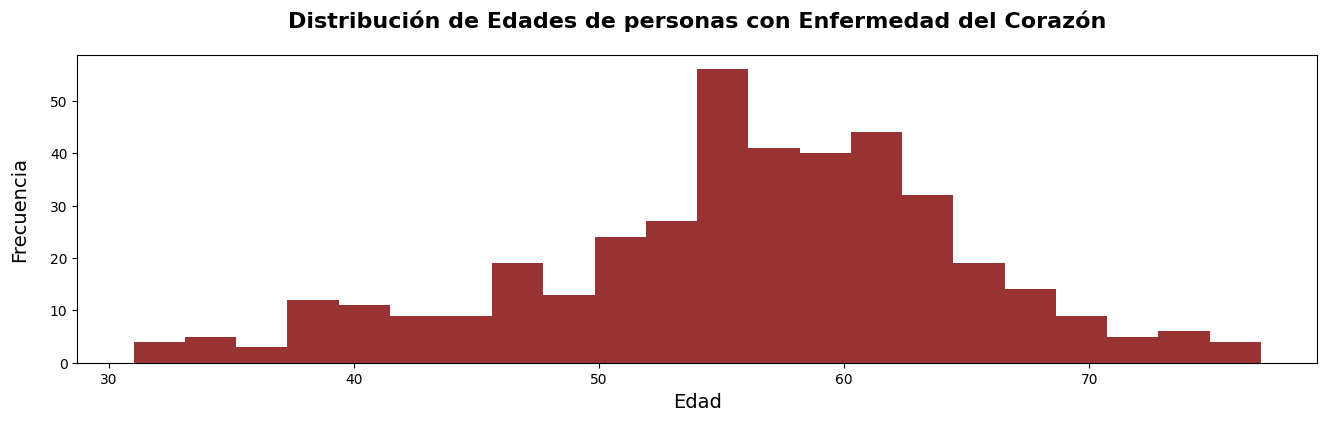

In [ ]:
fig, axes = plt.subplots(figsize=(16, 4))
age_of_people_with_heart_disease = heart_data[heart_data['HeartDisease'] == 1]['Age']

axes.hist(age_of_people_with_heart_disease, bins=22, color='maroon', alpha=0.8)
axes.set_title('Distribución de Edades de personas con Enfermedad del Corazón', fontsize=16, fontweight='bold', pad=20)
axes.set_xlabel('Edad',  fontsize=14)
axes.set_ylabel('Frecuencia', fontsize=14, labelpad=15)
plt.show()

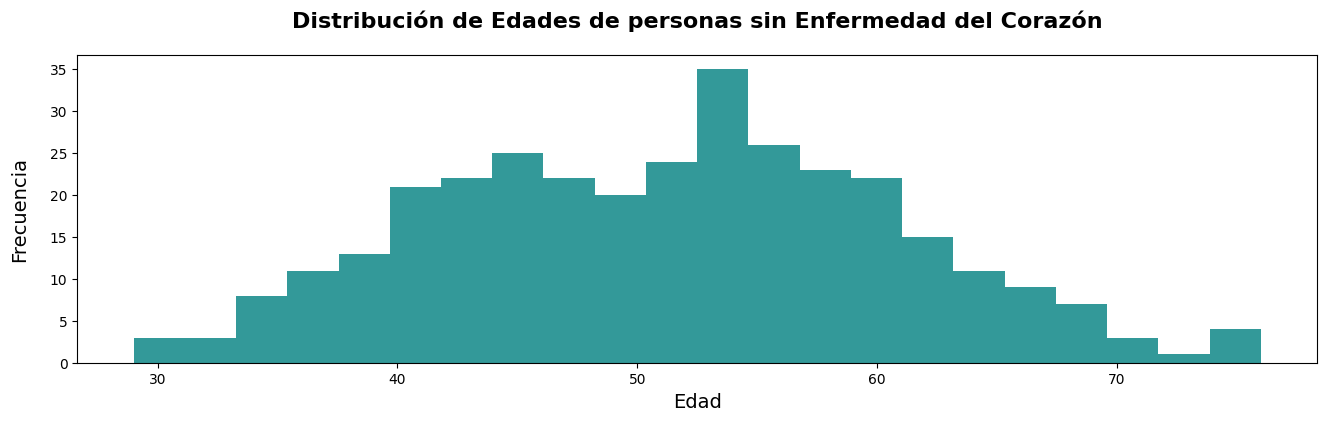

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))
age_of_people_without_heart_disease = heart_data[heart_data['HeartDisease'] == 0]['Age']

ax.hist(age_of_people_without_heart_disease, bins=22, color='teal', alpha=0.8)
ax.set_title('Distribución de Edades de personas sin Enfermedad del Corazón', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Edad',  fontsize=14)
ax.set_ylabel('Frecuencia', fontsize=14, labelpad=15)
plt.show()

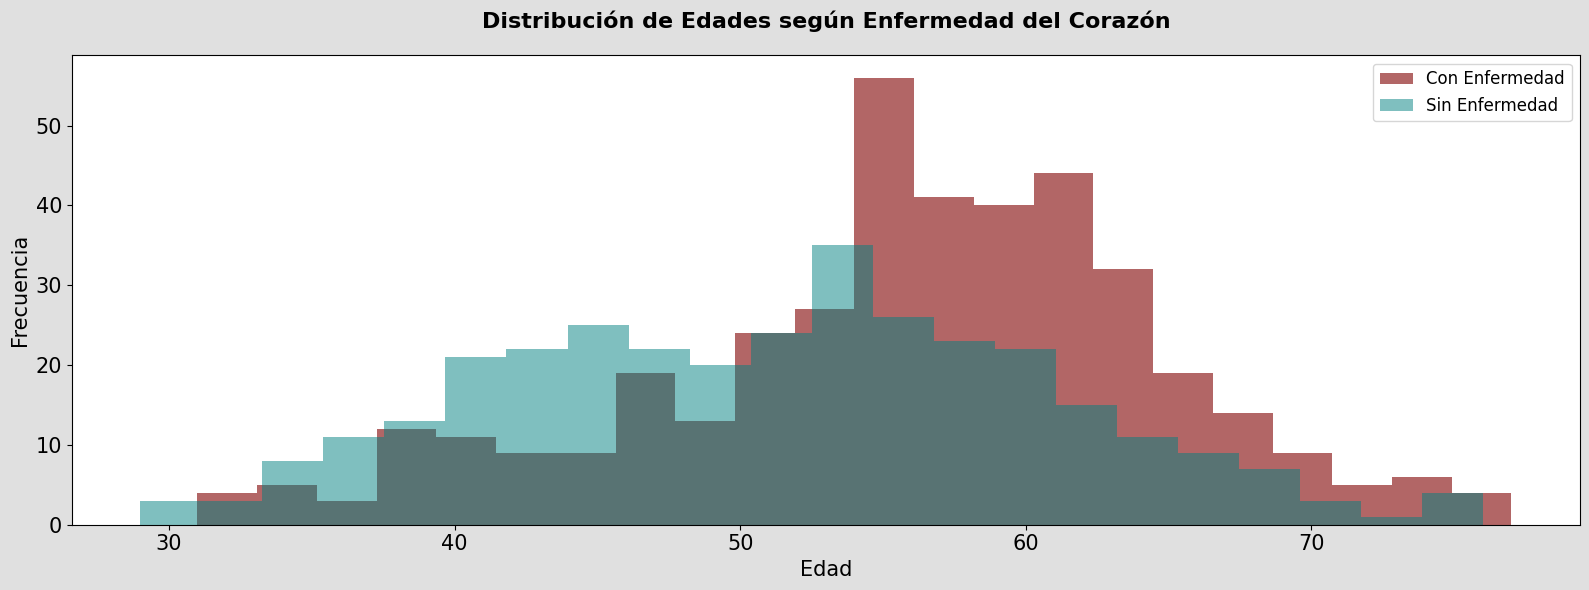

In [ ]:
#datos encimado:
fig, ax = plt.subplots(figsize=(16, 6), facecolor = '#e0e0e0')

age_hd = heart_data[heart_data['HeartDisease'] == 1]['Age']
age_no_hd = heart_data[heart_data['HeartDisease'] == 0]['Age']

ax.hist(age_hd, bins=22, color='maroon', alpha=0.6, label='Con Enfermedad')
ax.hist(age_no_hd, bins=22, color='teal', alpha=0.5, label='Sin Enfermedad')

ax.set_title('Distribución de Edades según Enfermedad del Corazón', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Edad', fontsize=15)
ax.set_ylabel('Frecuencia', fontsize=15)
ax.tick_params(axis='both', labelsize=15)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


## Analisis Sexo


In [ ]:
heart_data['Sex'].value_counts()

,count
Sex,
M,579
F,155


In [ ]:
heart_data.groupby(['Sex', 'HeartDisease']).size()

Sex  HeartDisease
F    0               111
     1                44
M    0               217
     1               362
dtype: int64

In [ ]:
sex_count = heart_data[heart_data['HeartDisease']==1]['Sex'].value_counts()
sex_count

,count
Sex,
M,362
F,44


In [ ]:
#Mapeo para mayor claridad en la visu
sex_count.index = sex_count.index.map({'F': 'Femenino', 'M': 'Masculino'})

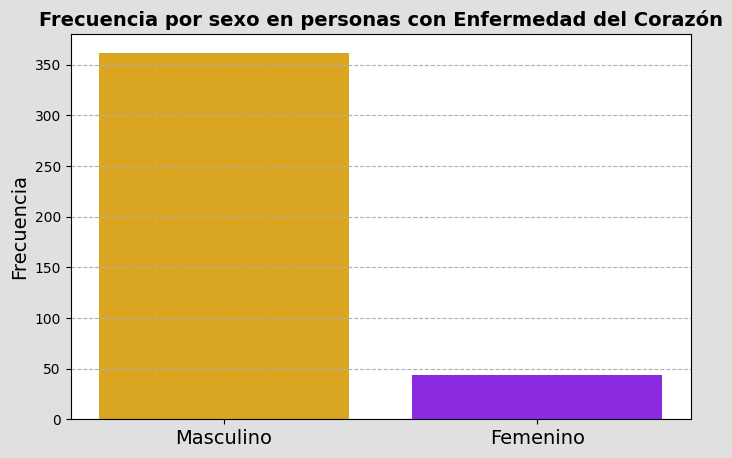

In [ ]:
plt.figure(figsize=(8, 5), facecolor = '#e0e0e0')
plt.bar(sex_count.index, sex_count.values, color=['goldenrod', 'blueviolet'])
plt.title('Frecuencia por sexo en personas con Enfermedad del Corazón', fontsize=14, fontweight='bold')
plt.ylabel('Frecuencia', fontsize=14)
plt.xticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

## Ayuno y colesterol

Primero vemos los datos numericos de colesterol

In [ ]:
heart_data['Cholesterol'].describe()

,Cholesterol
count,734.000000
mean,203.227520
std,108.402067
min,0.000000
25%,180.000000
50%,225.000000
75%,269.750000
max,603.000000


Hya que corregir el dato invalido de 0 de colesterol, no es correcto en el dominio del problema

In [ ]:
# hay mucho colesterol 0 y esto es un error del dominio, se reemplaza por nands
heart_data['Cholesterol'] = heart_data['Cholesterol'].replace(0, np.nan)
heart_data['Cholesterol'].describe()

,Cholesterol
count,605.000000
mean,246.560331
std,59.656537
min,85.000000
25%,210.000000
50%,238.000000
75%,277.000000
max,603.000000


In [ ]:
heart_data.groupby('FastingBS')[['Cholesterol', 'HeartDisease']].mean()

,Cholesterol,HeartDisease
FastingBS,,
0,245.330709,0.482332
1,253.000000,0.791667


## Relacion Dolor de Pecho, Test electrocardiograma en reposo y Colesterol

In [ ]:
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,63,M,ATA,139,217.0,1,ST,128,Y,1.2,Flat,1
1,55,M,ATA,110,214.0,1,ST,180,N,0.4,Up,0
2,59,F,ASY,130,338.0,1,ST,130,Y,1.5,Flat,1
3,47,M,ASY,160,NaN,0,Normal,124,Y,0.0,Flat,1
4,50,M,ASY,145,NaN,1,Normal,139,Y,0.7,Flat,1


In [ ]:
heart_data['ChestPainType'].value_counts()

,count
ChestPainType,
ASY,403
NAP,155
ATA,136
TA,40


In [ ]:
heart_data['RestingECG'].value_counts()

,count
RestingECG,
Normal,447
LVH,146
ST,141


In [ ]:
heart_data.groupby(['RestingECG', 'ChestPainType'])['Cholesterol'].mean()

RestingECG  ChestPainType
LVH         ASY              260.671053
            ATA              263.166667
            NAP              253.709677
            TA               236.909091
Normal      ASY              247.812865
            ATA              244.602041
            NAP              236.662500
            TA               238.000000
ST          ASY              253.725806
            ATA              232.266667
            NAP              216.944444
            TA               209.428571
Name: Cholesterol, dtype: float64

In [ ]:
pivot_chest_pain_ECG = heart_data[heart_data['HeartDisease'] == 1].pivot_table(
    values='Cholesterol',
    index='ChestPainType',
    columns='RestingECG',
    aggfunc='mean'
)

pivot_chest_pain_ECG

RestingECG,LVH,Normal,ST
ChestPainType,,,
ASY,258.950000,249.877049,254.755556
ATA,265.000000,277.500000,249.666667
NAP,196.285714,243.166667,238.250000
TA,281.000000,242.250000,249.666667


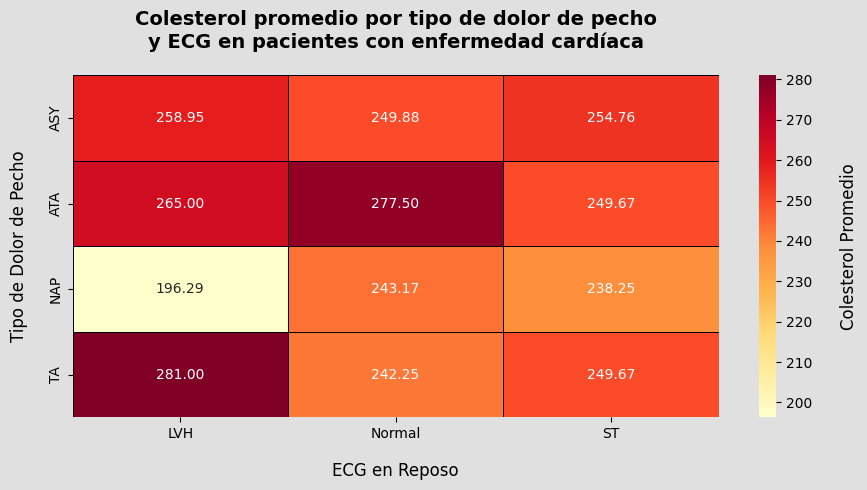

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor = '#e0e0e0') #aca el alto de la imagen entre 5 o 6, se ve mejor 5 en el notebook

sns.heatmap(pivot_chest_pain_ECG, annot=True, fmt=".2f", cmap='YlOrRd',
            linewidths=0.5, linecolor='black',
            cbar_kws={'label': 'Colesterol promedio'},
            ax=ax)

cbar = ax.collections[0].colorbar
cbar.set_label('Colesterol Promedio', fontsize=12, labelpad=20)
cbar.ax.tick_params(labelsize=10)

ax.set_title("Colesterol promedio por tipo de dolor de pecho\n"
             "y ECG en pacientes con enfermedad cardíaca",
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("ECG en Reposo", fontsize=12, labelpad=15)
ax.set_ylabel("Tipo de Dolor de Pecho", fontsize=12, labelpad=15)

plt.tight_layout()
plt.show()

## Old Peak y ST Slope


In [ ]:
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,63,M,ATA,139,217.0,1,ST,128,Y,1.2,Flat,1
1,55,M,ATA,110,214.0,1,ST,180,N,0.4,Up,0
2,59,F,ASY,130,338.0,1,ST,130,Y,1.5,Flat,1
3,47,M,ASY,160,NaN,0,Normal,124,Y,0.0,Flat,1
4,50,M,ASY,145,NaN,1,Normal,139,Y,0.7,Flat,1


In [ ]:
heart_data["ST_Slope"].value_counts()

,count
ST_Slope,
Flat,374
Up,313
Down,47


In [ ]:
heart_data.groupby("ST_Slope")['HeartDisease'].agg(['count', 'mean'])

,count,mean
ST_Slope,,
Down,47,0.829787
Flat,374,0.831551
Up,313,0.178914


In [ ]:
heart_data['Oldpeak'].describe()

,Oldpeak
count,734.000000
mean,0.865123
std,1.056964
min,-2.600000
25%,0.000000
50%,0.500000
75%,1.500000
max,5.600000


In [ ]:
heart_data.groupby('HeartDisease')['Oldpeak'].mean()

,Oldpeak
HeartDisease,
0,0.422561
1,1.222660


In [ ]:
heart_data.groupby('ST_Slope')['Oldpeak'].describe()

,count,mean,std,min,25%,50%,75%,max
ST_Slope,,,,,,,,
Down,47.0,2.212766,1.380551,-1.5,1.4,2.0,3.05,5.6
Flat,374.0,1.166310,1.013125,-2.6,0.0,1.0,2.00,5.0
Up,313.0,0.302875,0.645813,-1.1,0.0,0.0,0.20,4.0


/tmp/ipython-input-83-3077686434.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)


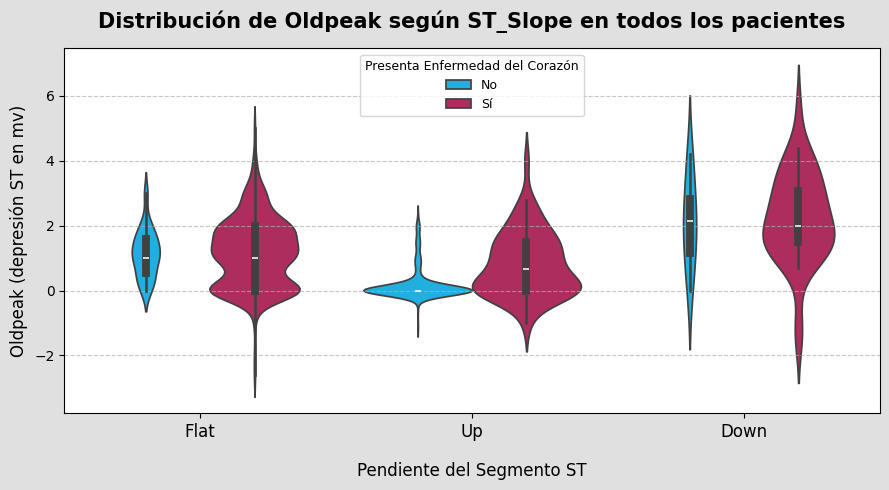

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor = '#e0e0e0') #aca puedoponer facecolor, color de fondo

sns.violinplot(
    data=heart_data,
    hue='HeartDisease',
    x='ST_Slope',
    y='Oldpeak',
    palette = ["#00BFFF", "#c2185b"],
    ax=ax
)

ax.set_title('Distribución de Oldpeak según ST_Slope en todos los pacientes', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Pendiente del Segmento ST', fontsize=12, labelpad=15)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_ylabel('Oldpeak (depresión ST en mv)', fontsize=12)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['No', 'Sí'], title='Presenta Enfermedad del Corazón', loc='upper center', fontsize=9, title_fontsize=9, frameon=True)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Sintomas y medidas post ejercicio (Exercise Angina y MaxHR)

In [ ]:
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,63,M,ATA,139,217.0,1,ST,128,Y,1.2,Flat,1
1,55,M,ATA,110,214.0,1,ST,180,N,0.4,Up,0
2,59,F,ASY,130,338.0,1,ST,130,Y,1.5,Flat,1
3,47,M,ASY,160,NaN,0,Normal,124,Y,0.0,Flat,1
4,50,M,ASY,145,NaN,1,Normal,139,Y,0.7,Flat,1


In [ ]:
heart_data.groupby('ExerciseAngina')['HeartDisease'].value_counts().unstack()

HeartDisease,0,1
ExerciseAngina,,
N,282,152
Y,46,254


In [ ]:
heart_data['MaxHR'].describe()

,MaxHR
count,734.000000
mean,136.377384
std,25.832297
min,60.000000
25%,119.000000
50%,138.000000
75%,156.000000
max,202.000000


In [ ]:
heart_data.groupby('ExerciseAngina')['MaxHR'].mean()

,MaxHR
ExerciseAngina,
N,144.156682
Y,125.123333


/tmp/ipython-input-36-4199298699.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sí","No"], fontsize=12)


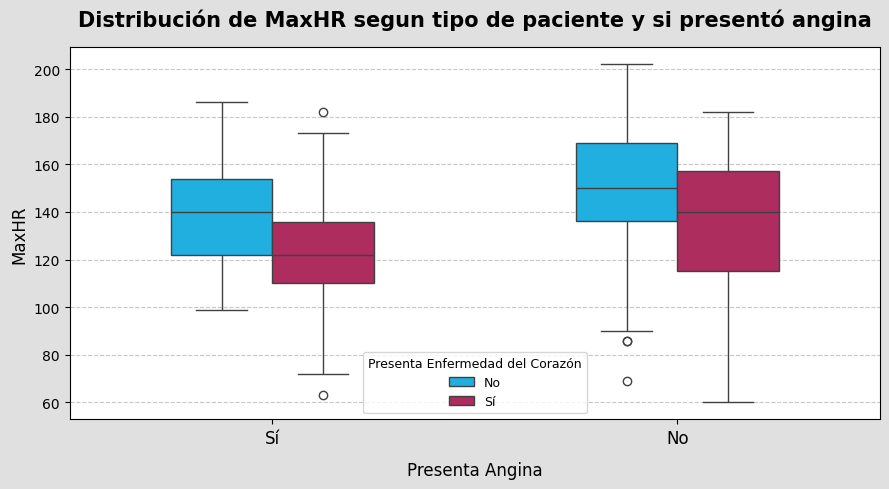

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor = '#e0e0e0')

sns.boxplot(
    data=heart_data,
    hue='HeartDisease',
    x='ExerciseAngina',
    y='MaxHR',
    palette = ["#00BFFF", "#c2185b"],
    dodge=True,
    width= 0.5,
    ax=ax
)

ax.set_title('Distribución de MaxHR segun tipo de paciente y si presentó angina', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Presenta Angina', fontsize=12, labelpad=10)
ax.set_xticklabels(["Sí","No"], fontsize=12)
ax.set_ylabel('MaxHR', fontsize=12)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['No', 'Sí'], title='Presenta Enfermedad del Corazón', fontsize=9, title_fontsize=9, frameon=True)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Distribucion Resting BP segun Target

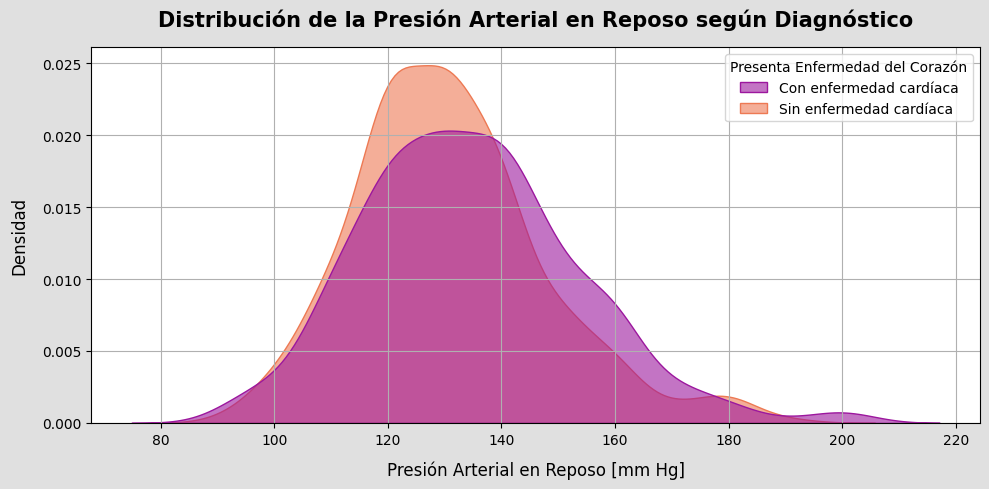

In [ ]:
heart_data_plot = heart_data.copy()
heart_data_plot['Presenta Enfermedad del Corazón'] = heart_data_plot['HeartDisease'].map({
    0: 'Sin enfermedad cardíaca',
    1: 'Con enfermedad cardíaca'
})

plt.figure(figsize=(10, 5), facecolor = '#e0e0e0')
sns.kdeplot(
    data=heart_data_plot,
    x='RestingBP',
    hue='Presenta Enfermedad del Corazón',
    fill=True,
    palette='plasma',
    common_norm=False,
    alpha=0.6
)
plt.title('Distribución de la Presión Arterial en Reposo según Diagnóstico', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Presión Arterial en Reposo [mm Hg]', fontsize=12, labelpad=10)
plt.ylabel('Densidad', fontsize=12, labelpad=10)
plt.grid(True)
plt.tight_layout()
plt.show()

## Relacion Edad con Resting BS

In [ ]:
heart_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,63,M,ATA,139,217.0,1,ST,128,Y,1.2,Flat,1
1,55,M,ATA,110,214.0,1,ST,180,N,0.4,Up,0
2,59,F,ASY,130,338.0,1,ST,130,Y,1.5,Flat,1
3,47,M,ASY,160,NaN,0,Normal,124,Y,0.0,Flat,1
4,50,M,ASY,145,NaN,1,Normal,139,Y,0.7,Flat,1


In [ ]:
heart_data.groupby('HeartDisease')[['RestingBP', 'Age']].mean()

,RestingBP,Age
HeartDisease,,
0,130.823171,51.280488
1,134.532020,55.923645


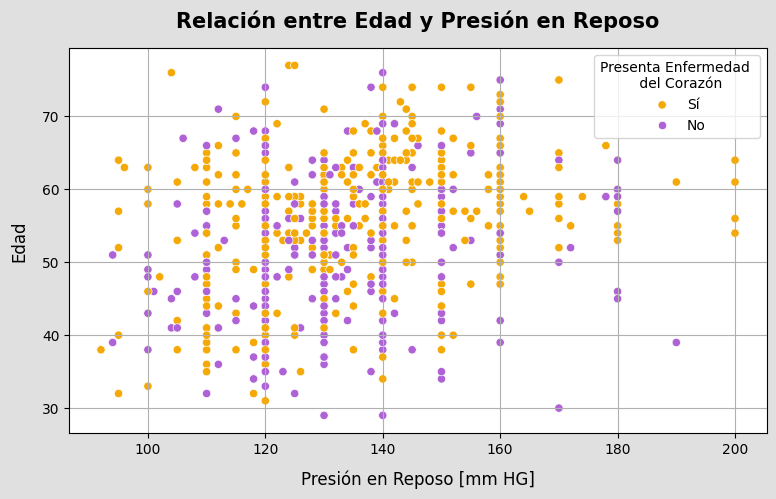

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor = '#e0e0e0')
sns.scatterplot(
    data=heart_data,
    x='RestingBP',
    y='Age',
    hue='HeartDisease',
    palette = ["#af61d6", "#f5a906"])

ax.set_title('Relación entre Edad y Presión en Reposo', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Presión en Reposo [mm HG]', fontsize=12, labelpad=10)
ax.set_ylabel('Edad', fontsize=12, labelpad=10)
ax.legend(['Sí', 'No'], title='Presenta Enfermedad \n         del Corazón',
         fontsize=10, title_fontsize=10, frameon=True)
plt.grid(True)
plt.show()